In [1]:
import torch
import time

# 模拟一个巨大的矩阵运算
a = torch.randn(10000, 10000).cuda()
b = torch.randn(10000, 10000).cuda()

print("开始 GPU 压力测试...")
start = time.time()
for _ in range(100):
    c = torch.matmul(a, b)
torch.cuda.synchronize() # 等待计算完成
print(f"100次大矩阵乘法耗时: {time.time() - start:.4f}s")

开始 GPU 压力测试...
100次大矩阵乘法耗时: 6.7974s


这个 .pth 文件里的所有键（Keys）有： dict_keys(['model', 'results', 'hyperparameters'])


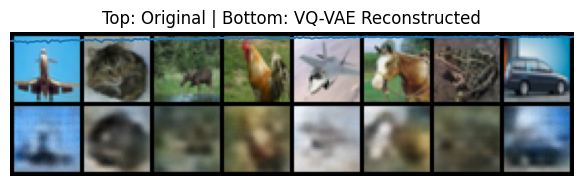

In [10]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from torchvision.utils import make_grid
import utils
from models.vqvae import VQVAE

# 配置
PATH = 'results/vqvae_data_wed_feb_25_15_35_08_2026.pth'
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# 在这一行之前：checkpoint = torch.load(...)
print("这个 .pth 文件里的所有键（Keys）有：", checkpoint.keys())
# 1. 加载数据
checkpoint = torch.load(PATH, map_location=device, weights_only=False)
hps = checkpoint['hyperparameters']

# 2. 初始化模型 (使用你刚才查到的参数名)
model = VQVAE(
    h_dim=hps['n_hiddens'],
    res_h_dim=hps['n_residual_hiddens'],
    n_res_layers=hps['n_residual_layers'],
    n_embeddings=hps['n_embeddings'],
    embedding_dim=hps['embedding_dim'],
    beta=hps['beta']
).to(device)

model.load_state_dict(checkpoint['model'])
model.eval()

# 3. 绘图：Recon Error
plt.figure(figsize=(16, 4))
plt.subplot(1, 2, 1)
plt.plot(checkpoint['results']['recon_errors'])
plt.title('Recon Error (Lower is Better)')

# 4. 绘图：重建对比
# 1. 修改后的加载行
_, _, _, val_loader, _ = utils.load_data_and_data_loaders('CIFAR10', 8)

# 2. 获取测试图片
(x, _) = next(iter(val_loader))
x = x.to(device)

# 3. 显卡开始“洗画”
with torch.no_grad():
    _, x_hat, _ = model(x)

# 4. 展示对比
import matplotlib.pyplot as plt
from torchvision.utils import make_grid

grid = make_grid(torch.cat([x, x_hat]), nrow=8, normalize=True)
plt.imshow(grid.cpu().permute(1, 2, 0))
plt.axis('off')
plt.title('Top: Original | Bottom: VQ-VAE Reconstructed')
plt.show()

In [6]:
import inspect
from models.vqvae import VQVAE
# 打印构造函数的参数名
print("VQVAE 真正需要的参数是：", inspect.signature(VQVAE.__init__))

VQVAE 真正需要的参数是： (self, h_dim, res_h_dim, n_res_layers, n_embeddings, embedding_dim, beta, save_img_embedding_map=False)
